# Applied Data Science - Exercise 5

This is the fifth and final exercise in the course T-786-APDS Applied Data Science at Reykjavik University.

## Preparation

Please refer to the lecture slides from the course for the lab. 

## Task

You continue on your mission to predict listed car prices. As before, you will be using the second hand car listing data crawled from Craigslist (`vehicles.csv`).

To recap our progress so far, we have:

* Explored the dataset, visualized the data, and gained insights
* Prepared the data for machine learning algorithms
* Used the Scikit-learn library to train a few different regression models on our training data and tuned hyper-parameters using cross-validation.
* Interpreted the resulting models to gain understanding of our models (e.g. why different predictions were being made).

In this exercise, you will recap and integrate what you have learned across previous assignments, plus new methods introduced here.

You are tasked with creating the best prediction model possible based on your intiutions around exploring the data, playing with the different models and understanding of the model outcomes. 

Remember: You are a good modeler when you can explain it well to even a layperson.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
import sys

In [2]:
# Check python version.
# This code should run for python version >=3.6

print("python", sys.version)

python 3.12.10 (tags/v3.12.10:0cc8128, Apr  8 2025, 12:21:36) [MSC v.1943 64 bit (AMD64)]


## Data import and preprocessing

We start by importing the data and getting it ready for machine learning as before. 

**Task:** But now you are required to add/change some of the steps in the preprocessing step (possibly encoding methods) based on your subjective exploration done in Assignment 1 and 2: 

In [3]:
vehicles = pd.read_csv("../Ass1/vehicles.csv", index_col=0)

In [ ]:
reduced_df = vehicles.copy()
reduced_df = reduced_df[reduced_df['price'] > 0]
reduced_df = reduced_df[reduced_df['price'].notna()]
reduced_df = reduced_df[reduced_df['price'] < 1000000]
reduced_df = reduced_df[~reduced_df.manufacturer.isnull()]  
reduced_df = reduced_df.drop(columns=[
    'county', 
    'id', 
    'region_url', 
    'url', 
    'image_url', 
    'VIN'
])
reduced_df

**Question:**  Would adding the msrp dataset to our reduced_df help in our price prediction task? Why or Why not?

**Answer:**  `<TODO>`

In [5]:
from sklearn.model_selection import train_test_split

vehicles_train_set, vehicles_test_set = train_test_split(reduced_df, test_size=0.1, random_state=123)
vehicles_train_set, vehicles_val_set = train_test_split(vehicles_train_set, train_size=0.95) 

In [ ]:
def preprocess(df_in):
    
    df = df_in.copy()
    
    N = 50
    topN_models = df.model.value_counts().head(N).index.to_numpy()
    df.loc[~df['model'].isin(topN_models),'model'] = 'unknown'
    top_models = list(vehicles_train_set.model.unique())
    
    df = df.drop(columns=[
        'size', 
        'drive', 
        'lat', 
        'long', 
        'posting_date', 
        'paint_color', 
        'description',
        'state',
        'region'
    ])
    
    df.loc[~df['model'].isin(top_models),'model'] = 'unknown'
    
    df = df.dropna(subset=['year', 'odometer','manufacturer'])
    df['type'].fillna('unknown',inplace=True)
    df['title_status'].fillna('clean', inplace=True)
    df['fuel'].fillna('gas', inplace=True)
    df['cylinders'].fillna('unknown', inplace=True)
    df['transmission'].fillna('automatic', inplace=True)
    df['condition'].fillna('good', inplace=True)
    
    
    X = df.drop('price', axis=1)
    y = df['price'].copy()
    
    return(X,y)

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

X, y = preprocess(vehicles_train_set)

num_attribs = list(X.select_dtypes('number'))
cat_attribs = list(X.select_dtypes('object'))


pipeline = ColumnTransformer([
    ('num', StandardScaler(), num_attribs),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_attribs)
])

X_prepared = pipeline.fit_transform(X)

C:\Users\dgrim\AppData\Local\Temp\ipykernel_6976\330943606.py:25: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['type'].fillna('unknown',inplace=True)
C:\Users\dgrim\AppData\Local\Temp\ipykernel_6976\330943606.py:26: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, whe

**Question:**  What did you change in the above code to preprocess the dataset? How do you justify your action?

**Answer:**  `<TODO>`

## Model building and hyperparameter optimisation

**Task:** Pick a model from Assignment 3 that you believe would suit this task well. Train your model on the training set and choose a set of hyperparameters. Justify the selection of hyperparameters. 

In [10]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=123,
    n_jobs=-1
)

rf_model.fit(X_prepared, y)

RandomForestRegressor(max_depth=20, min_samples_leaf=2, min_samples_split=5,
                      n_estimators=200, n_jobs=-1, random_state=42)

**Task:** Evaluate your model on the validation set to diagnose underfitting or overfitting

In [11]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Preprocess validation data
X_val, y_val = preprocess(vehicles_val_set)
X_val_prepared = pipeline.transform(X_val)

# Predictions
train_preds = rf_model.predict(X_prepared)
val_preds = rf_model.predict(X_val_prepared)

# Training metrics
train_rmse = np.sqrt(mean_squared_error(y, train_preds))
train_r2 = r2_score(y, train_preds)

# Validation metrics
val_rmse = np.sqrt(mean_squared_error(y_val, val_preds))
val_r2 = r2_score(y_val, val_preds)

print("Training RMSE:", train_rmse)
print("Training R²:", train_r2)

print("Validation RMSE:", val_rmse)
print("Validation R²:", val_r2)

C:\Users\dgrim\AppData\Local\Temp\ipykernel_6976\330943606.py:25: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['type'].fillna('unknown',inplace=True)
C:\Users\dgrim\AppData\Local\Temp\ipykernel_6976\330943606.py:26: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, whe

Training RMSE: 6053.285530113658
Training R²: 0.8385995102460909
Validation RMSE: 13128.134066091858
Validation R²: 0.5332580205753386


**Question:**  What are the RMSE value from the above sets? Can we do a direct comparison of these values to validate the model?

**Answer:**  `Training RMSE 6053, R^2 0.84, Validation RMSE 13128, R^2 0.53, We should be able to diretly compare these values because we are trying to see if it generalizes, we do see that the numbers dont line up well, the training data shows much better results than the validation set so this suggests overfitting because the model the validation set contains data the model never saw in training so it dosent generalize as well as we would like`

**Task:** Use nested cross-validation to select the best hyperparameters and estimate the error on a RandomForestRegressor model. 

Hint: Use the whole training set (vehicles_train_set) for this task. 

(this could be computationally expensive, so you can use a subset of the training set for this task or use number of splits wisely)

In [ ]:
from sklearn.model_selection import GridSearchCV, cross_val_score, KFold
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestRegressor

inner_cv = KFold(n_splits=3, shuffle=True, random_state=42)
outer_cv = KFold(n_splits=3, shuffle=True, random_state=42)

rf_model = RandomForestRegressor(random_state=42)

param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [10, 15]
}

grid_search = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    cv=inner_cv,
    scoring='r2',
    n_jobs=-1
)

nested_scores = cross_val_score(
    grid_search,
    X_prepared,
    y,
    cv=outer_cv,
    scoring='r2',
    n_jobs=-1
)

print("Nested CV R² Scores:", nested_scores)
print("Mean R²:", np.mean(nested_scores))
print("Std R²:", np.std(nested_scores))

KeyboardInterrupt: 

In [17]:
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.ensemble import RandomForestRegressor
import numpy as np


# Rand it a few times with different n estimators and depth because of time constraints, 100 was better than 50 and 150 was better than 150 but 150 was not better than 200.
np.random.seed(42)
idx = np.random.choice(X_prepared.shape[0], 50000, replace=False)

X_small = X_prepared[idx]
y_small = y.iloc[idx]

inner_cv = KFold(n_splits=3, shuffle=True, random_state=42)
outer_cv = KFold(n_splits=3, shuffle=True, random_state=42)

rf_model = RandomForestRegressor(random_state=42, n_jobs=-1)

param_grid = {
    'n_estimators': [100, 150],
    'max_depth': [10, 15]
}


outer_scores = []
best_params_per_fold = []


for train_idx, test_idx in outer_cv.split(X_small):

    X_train, X_test = X_small[train_idx], X_small[test_idx]
    y_train, y_test = y_small.iloc[train_idx], y_small.iloc[test_idx]

    grid_search = GridSearchCV(
        estimator=rf_model,
        param_grid=param_grid,
        cv=inner_cv,
        scoring='r2',
        n_jobs=-1
    )

    grid_search.fit(X_train, y_train)

    best_model = grid_search.best_estimator_

    best_params_per_fold.append(grid_search.best_params_)

    score = best_model.score(X_test, y_test)
    outer_scores.append(score)


print("Nested CV R² Scores:", outer_scores)
print("Mean R²:", np.mean(outer_scores))
print("Std R²:", np.std(outer_scores))

print("\nBest hyperparameters per fold:")
for i, params in enumerate(best_params_per_fold):
    print(f"Fold {i+1}: {params}")

Nested CV R² Scores: [0.7292544827086288, 0.7138345437552378, 0.7116460669369907]
Mean R²: 0.7182450311336191
Std R²: 0.00783595880892967

Best hyperparameters per fold:
Fold 1: {'max_depth': 15, 'n_estimators': 150}
Fold 2: {'max_depth': 15, 'n_estimators': 150}
Fold 3: {'max_depth': 15, 'n_estimators': 150}


We find the best model. We fit it to the training data and call the model est

In [18]:
forest_reg = RandomForestRegressor(max_features=15, max_depth=15, n_estimators=150, random_state=42)
est=forest_reg

Apply the model to the test data

In [20]:
est.fit(X_prepared, y)

RandomForestRegressor(max_depth=15, max_features=15, n_estimators=150,
                      random_state=42)

## Methods for model interpretation

SHAP

The goal of SHAP is to explain the prediction of an instance x by computing the contribution of each feature to the prediction.

The SHAP explanation method computes Shapley values from coalitional game theory

Shapley values tell us how to fairly distribute the “payout” (= the prediction) among the features

In [23]:
import shap
# This takes a while to run
X_sample = X_prepared[:1000].toarray()
explainer = shap.Explainer(est)
shap_values = explainer.shap_values(X_sample, approximate=False, check_additivity=False)

C:\Users\dgrim\AppData\Local\Temp\ipykernel_6976\3891084168.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_sample)


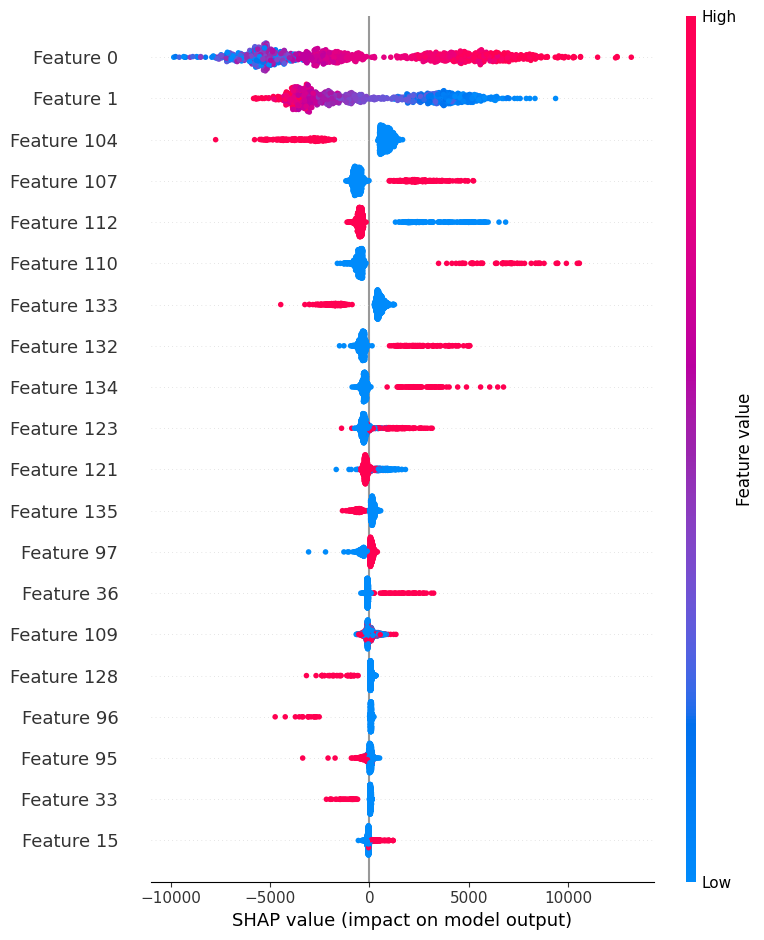

In [26]:
shap.summary_plot(shap_values, X_sample)

In [27]:
shap.plots.bar(shap_values)

TypeError: The shap_values argument must be an Explanation object, Cohorts object, or dictionary of Explanation objects!

**Task:** Use one more method of model interpretation from Assignment 4 that would help explain the influence of features in your model.

In [ ]:
<TODO>

**Question:**  Do the method you chose and SHAP agree with each other in the interpretation?

**Answer:**  `<TODO>`

**Question:**  Discuss how possible biases could have crept in while building the above model from scratch.

**Answer:**  `<TODO>`

## Classification 

But unlike the last time we will not drop some of the features. We will use all the features to predict the type of the vehicle.

In [ ]:
msrp_df = pd.read_csv("../../data/published/msrp.csv")

In [ ]:
msrp_df['is_luxury'] = msrp_df.market_category.str.contains('Luxury')

In [ ]:
for col in msrp_df.columns:
    new_col = '_'.join(col.lower().split(' '))
    msrp_df.rename({col: new_col}, inplace=True, axis=1)

In [ ]:
msrp_train_set, msrp_test_set = train_test_split(
    msrp_df.dropna(subset=['is_luxury']), 
    test_size=0.1, 
    random_state=123)
msrp_train_df = msrp_train_set.copy()

You now again have full freedom on how to shape the dataset:

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

def preprocess_msrp(df_in):

    <TODO>
    
    return(X,y)

X, y = preprocess_msrp(msrp_train_set)

num_attribs = list(X.select_dtypes('number'))
cat_attribs = list(X.select_dtypes('object'))

pipeline = ColumnTransformer([
    ('num', StandardScaler(), num_attribs),
    ('cat', OneHotEncoder(), cat_attribs)
])

X_prepared = pipeline.fit_transform(X)    

**Task:** Train one binary classification model from Assignment 3 on the training set and report accuracy, confusion matrix, precision, recall, F$_1$ score, Precision-recall curve and AUC-ROC curve for both training and test sets.

In [ ]:
<TODO>

Staistical testing to compare the two models

**Question:** Discuss the results of the above model. What would you potentially do to improve the model if given enough resources and time?

**Answer:** <TODO>

**Task:** Train a logistic regression model on the msrp data and compare the results using a statistical test to determine if your model is significantly better than logistic regression trained on the msrp data.

Hint: Extract y_pred = model.predict(X_test) for both and perform the statistic test taught in class.

In [ ]:
from sklearn.linear_model import LogisticRegression

<TODO>

In [ ]:
<TODO>

## You have now completed a End-to-end Machine Learning project in both Regression and Classification!!!

Congratulations and good luck with your project.